In [ ]:
# Install all required packages
%pip install torch torchvision xgboost scikit-learn opencv-python numpy matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# Imports all things in here

import os
import numpy as np
import cv2
import torch
import torch.nn as nn
from torchvision import models
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

import joblib

Using: cpu
cardboard : 404 images
glass : 502 images
metal : 411 images
paper : 595 images
plastic : 483 images
trash : 590 images
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

Label test:
0
cardboard


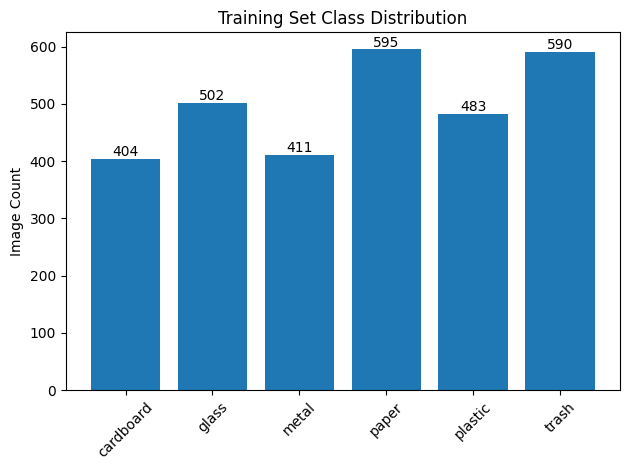

In [2]:
# Insert Dataset here (From google Drive) + GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

root = "dataset/"
for folder in os.listdir(root):
    path = os.path.join(root, folder)
    print(folder, ":", len(os.listdir(path)), "images")

dataset = datasets.ImageFolder("dataset/")
print(dataset.class_to_idx)

img, label = dataset[0]

print("\nLabel test:")
print(label)
print(dataset.classes[label])

# For graphing
counts = [len(os.listdir(os.path.join(root, cls))) for cls in dataset.classes]
bars = plt.bar(dataset.classes, counts)

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha='center'
    )

plt.xticks(rotation=45)
plt.ylabel("Image Count")
plt.title("Training Set Class Distribution")
plt.tight_layout()

In [3]:
# Prepare Dataset

torch.manual_seed(42) # Commment this out if u want random split images test/valid

#Transform dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(
        224,
        scale=(0.9,1.0),
        ratio=(0.9,1.1)
    ),
    transforms.ColorJitter(brightness=0.2,contrast=0.3,saturation=0.3,hue=0.1),
    transforms.RandomGrayscale(p=0.1),

    transforms.ToTensor()
])

#Save new augmented dataset
dataset = datasets.ImageFolder("dataset/",transform=transform)

#Split dataset
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Uncomment this 2 line for only training set and comment above
# dataset = datasets.ImageFolder("dataset/", transform=transform)
# train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

#Load dataset (Note: If u uncomment the 2 line above, unncomment this as well)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print("Images leak:",len(set(train_dataset.indices).intersection(set(test_dataset.indices))))
print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

Images leak: 0
Train dataset size: 2384
Test dataset size: 596


In [11]:
# Feature Extraction

model = models.mobilenet_v2(pretrained=True)
model = model.to(device)
model.classifier = nn.Identity()

for param in model.parameters():
    param.requires_grad = False

model.eval()


def edge_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)

    # feature 1: how much edge content exists
    edge_density = np.sum(edges) / edges.size

    return [edge_density]

def shape_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return [0, 0]

    largest = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(largest)
    perimeter = cv2.arcLength(largest, True)

    compactness = (perimeter ** 2) / (area + 1e-5)

    return [area, compactness]

def feature_extraction(loader, model):
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:

            # CNN features
            cnn_feat = model(images)

            batch_extra_features = []

            for img in images:
                img = img.permute(1, 2, 0).cpu().numpy()  # CHW → HWC
                img = (img * 255).astype(np.uint8)

                edge_feat = edge_features(img)
                shape_feat = shape_features(img)

                batch_extra_features.append(edge_feat + shape_feat)

            batch_extra_features = torch.tensor(batch_extra_features, dtype=torch.float32)

            # combine CNN + handcrafted
            final_feat = torch.cat([cnn_feat, batch_extra_features], dim=1)

            all_features.append(final_feat)
            all_labels.append(labels)

    return torch.cat(all_features), torch.cat(all_labels)

train_features, train_labels = feature_extraction(train_loader, model)
test_features, test_labels = feature_extraction(test_loader, model)

print("Train features shape:", train_features.shape)  # (n_samples, 1280)
print("Test features shape:", test_features.shape)

Train features shape: torch.Size([2384, 1283])
Test features shape: torch.Size([596, 1283])


c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:14:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7516778523489933
              precision    recall  f1-score   support

   cardboard       0.86      0.70      0.78        81
       glass       0.69      0.73      0.71        98
       metal       0.77      0.71      0.74        82
       paper       0.76      0.82      0.79       125
     plastic       0.70      0.69      0.69        80
       trash       0.76      0.79      0.77       130

    accuracy                           0.75       596
   macro avg       0.76      0.74      0.75       596
weighted avg       0.76      0.75      0.75       596



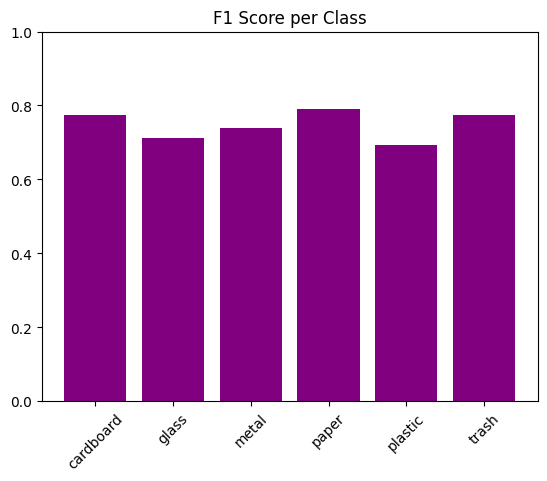

In [16]:
# Train + classification report
X_train = train_features.numpy()
y_train = train_labels.numpy()
X_test = test_features.numpy()
y_test = test_labels.numpy()

xgb = XGBClassifier(
    n_estimators=350,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

preds = xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds, target_names=dataset.classes))


report = classification_report(
    y_test,
    preds,
    target_names=dataset.classes,
    output_dict=True
)

f1_scores = [report[name]["f1-score"] for name in dataset.classes]

plt.bar(dataset.classes, f1_scores, color="purple")
plt.title("F1 Score per Class")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()

[[ 57   1   2   7   1  13]
 [  0  72   9   4  11   2]
 [  0  12  58   4   2   6]
 [  7   1   1 103   3  10]
 [  2  15   1   5  55   2]
 [  0   3   4  13   7 103]]


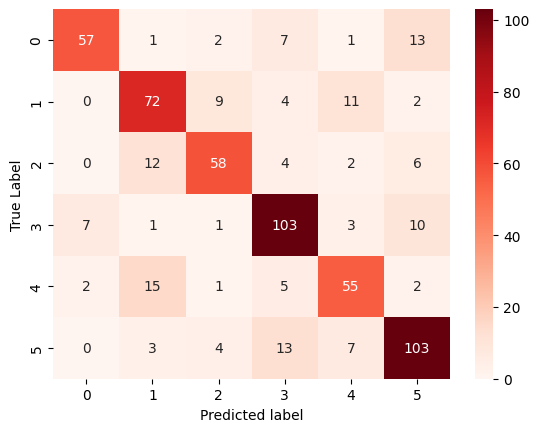

In [17]:
#Confusion Matrix
cm = confusion_matrix(y_test,preds)
print(cm)

sns.heatmap(cm, annot=True,fmt="d", cmap="Reds")
plt.xlabel("Predicted label")
plt.ylabel("True Label")
plt.show()

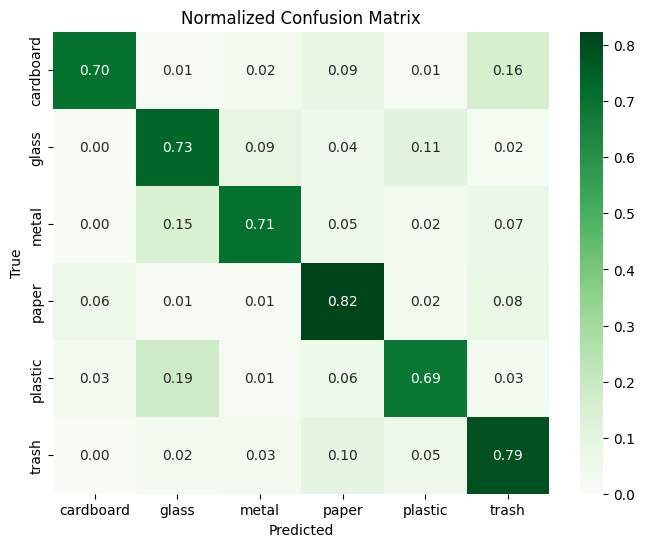

In [18]:
# 2# Test confusion matrix
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

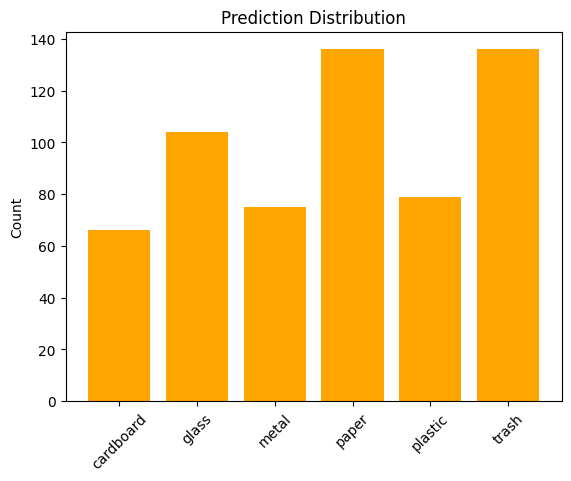

In [19]:
#Prediction Distribution
pred_counts = np.bincount(preds, minlength=len(dataset.classes))

plt.bar(dataset.classes, pred_counts, color="orange")
plt.title("Prediction Distribution")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

In [20]:

joblib.dump(xgb, 'model/classifier.pkl')            # save classifier
joblib.dump(dataset.classes, 'model/classes.pkl')    # saves model to a file


#model = joblib.load('model.pkl') 

['model/classes.pkl']